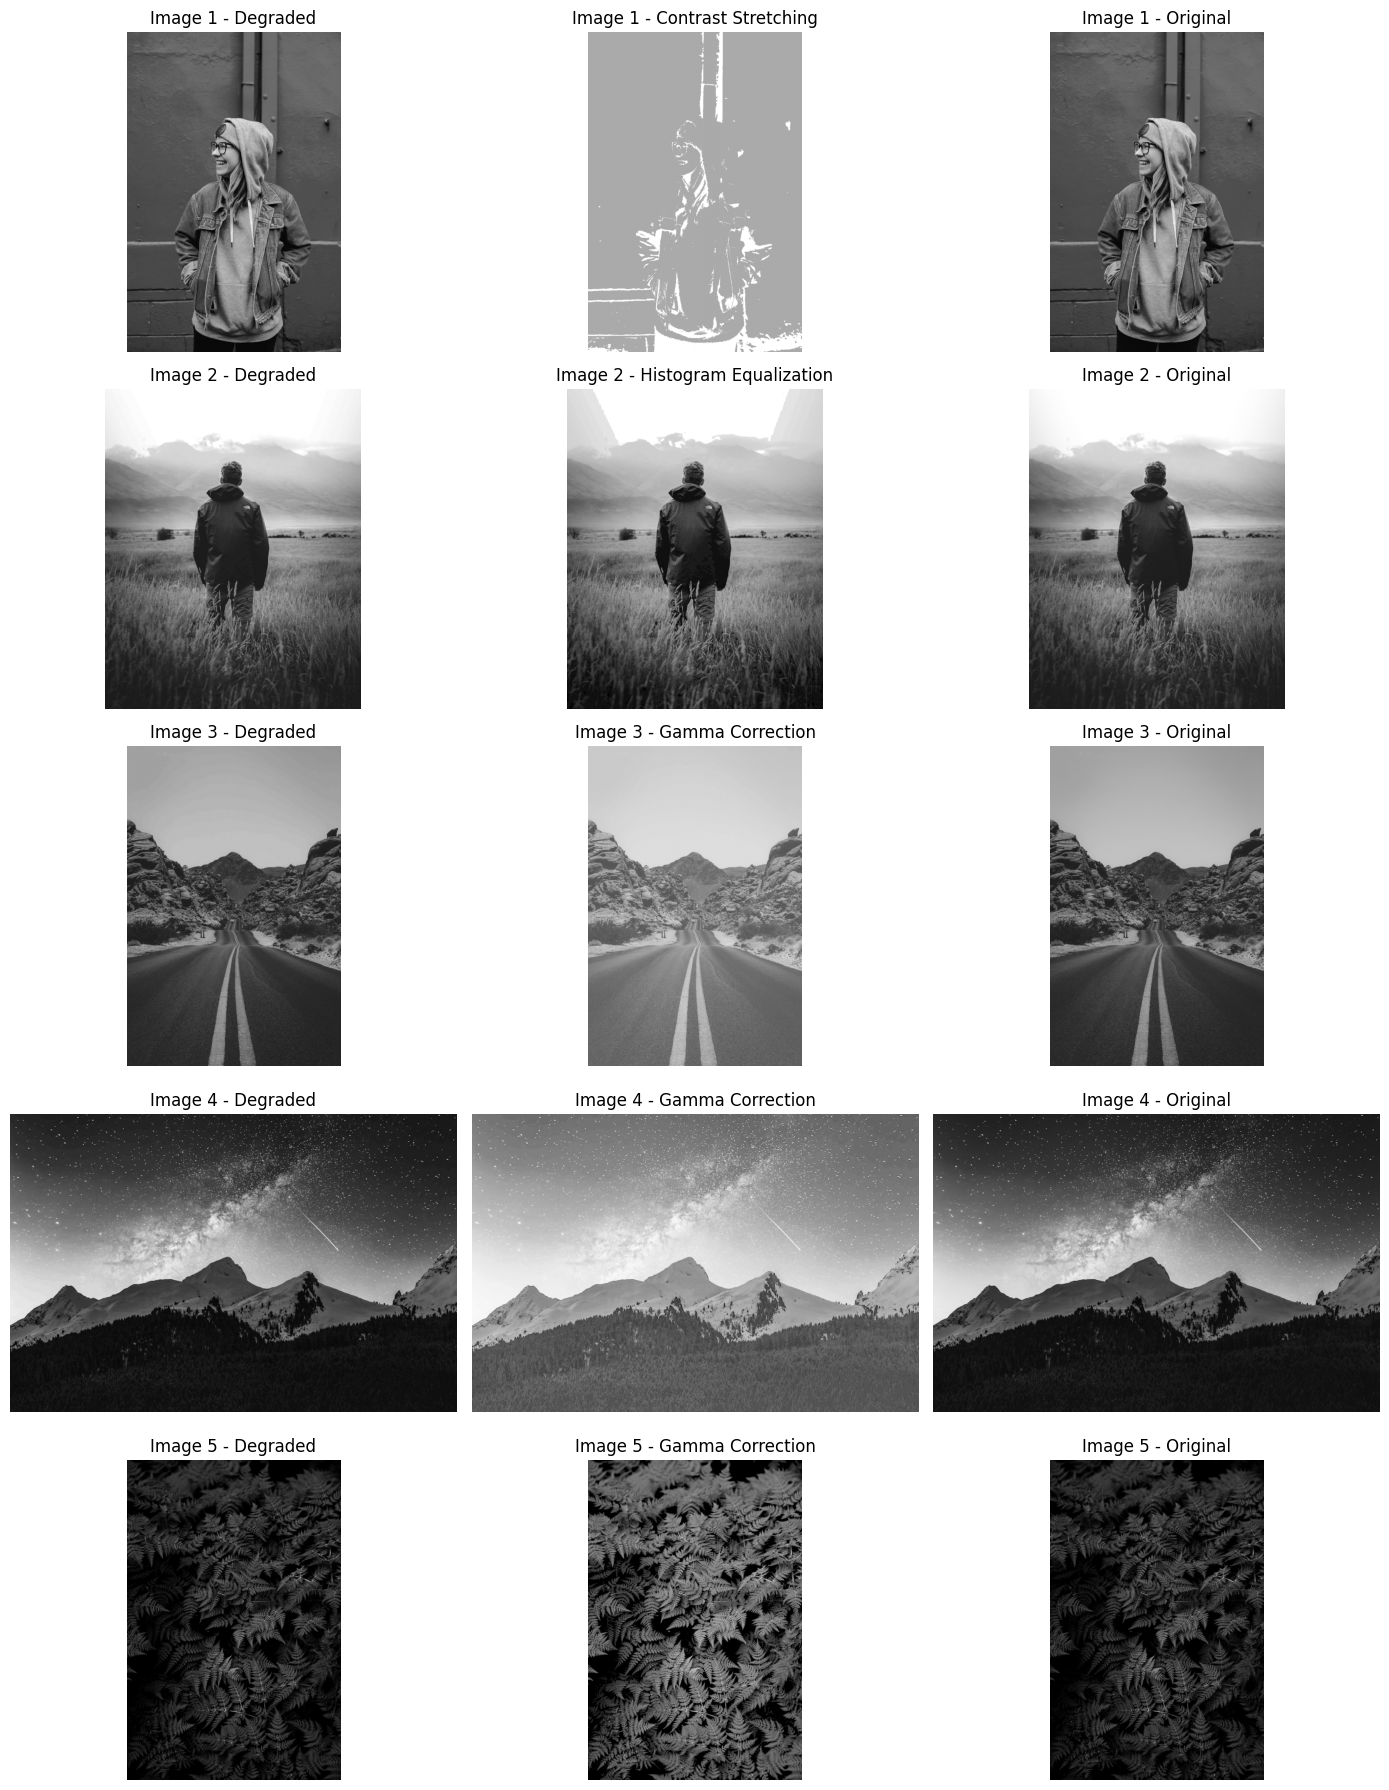


ALL FIVE IMAGES PROCESSED SUCCESSFULLY
Enhanced images saved successfully.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen


# ============================================================
# OPE 7
# Gray-Level Transformation Techniques for Image Enhancement
# ============================================================


# ------------------------------------------------------------
# Function to download image from URL
# ------------------------------------------------------------

def load_image_from_url(url):

    try:
        data = urlopen(url).read()

        image_array = np.asarray(
            bytearray(data),
            dtype=np.uint8
        )

        image = cv2.imdecode(
            image_array,
            cv2.IMREAD_GRAYSCALE
        )

        return image

    except Exception as e:

        print("Error loading image:", e)

        return None


# ------------------------------------------------------------
# Five online images
# ------------------------------------------------------------

image_urls = [

    # Image 1
    "https://images.unsplash.com/photo-1517841905240-472988babdf9?w=800",

    # Image 2
    "https://images.unsplash.com/photo-1503023345310-bd7c1de61c7d?w=800",

    # Image 3
    "https://images.unsplash.com/photo-1500530855697-b586d89ba3ee?w=800",

    # Image 4
    "https://images.unsplash.com/photo-1519681393784-d120267933ba?w=800",

    # Image 5
    "https://images.unsplash.com/photo-1497250681960-ef046c08a56e?w=800"
]


# ------------------------------------------------------------
# Load five images
# ------------------------------------------------------------

original_images = []

for i, url in enumerate(image_urls):

    print("Downloading Image", i + 1)

    image = load_image_from_url(url)

    if image is None:

        print("Unable to load Image", i + 1)

    else:

        original_images.append(image)


# ------------------------------------------------------------
# Check whether all images loaded
# ------------------------------------------------------------

if len(original_images) != 5:

    print("\nError: All five images could not be loaded.")
    exit()


# ============================================================
# CREATE FIVE DEGRADED IMAGES
# ============================================================


# ------------------------------------------------------------
# Image 1 - Low Contrast
# ------------------------------------------------------------

image1 = original_images[0]

degraded1 = cv2.normalize(
    image1,
    None,
    80,
    160,
    cv2.NORM_MINMAX
)


# ------------------------------------------------------------
# Image 2 - Low Contrast
# ------------------------------------------------------------

image2 = original_images[1]

degraded2 = cv2.normalize(
    image2,
    None,
    70,
    150,
    cv2.NORM_MINMAX
)


# ------------------------------------------------------------
# Image 3 - Dark Image
# ------------------------------------------------------------

image3 = original_images[2]

degraded3 = np.uint8(
    image3 * 0.30
)


# ------------------------------------------------------------
# Image 4 - Very Dark Image
# ------------------------------------------------------------

image4 = original_images[3]

degraded4 = np.uint8(
    image4 * 0.20
)


# ------------------------------------------------------------
# Image 5 - Dark Image
# ------------------------------------------------------------

image5 = original_images[4]

degraded5 = np.uint8(
    image5 * 0.25
)


# ============================================================
# GRAY-LEVEL ENHANCEMENT FUNCTIONS
# ============================================================


# ------------------------------------------------------------
# Contrast Stretching
# ------------------------------------------------------------

def contrast_stretching(image):

    minimum = np.min(image)

    maximum = np.max(image)

    if maximum == minimum:

        return image.copy()

    result = (
        (image - minimum)
        * 255
        / (maximum - minimum)
    )

    return np.uint8(result)


# ------------------------------------------------------------
# Histogram Equalization
# ------------------------------------------------------------

def histogram_equalization(image):

    return cv2.equalizeHist(image)


# ------------------------------------------------------------
# Gamma Correction
# ------------------------------------------------------------

def gamma_correction(image, gamma):

    normalized = image / 255.0

    corrected = np.power(
        normalized,
        gamma
    )

    corrected = np.uint8(
        corrected * 255
    )

    return corrected


# ============================================================
# APPLY ENHANCEMENT
# ============================================================


# Image 1
# Low contrast → Contrast Stretching

enhanced1 = contrast_stretching(
    degraded1
)


# Image 2
# Low contrast → Histogram Equalization

enhanced2 = histogram_equalization(
    degraded2
)


# Image 3
# Dark → Gamma Correction

enhanced3 = gamma_correction(
    degraded3,
    0.5
)


# Image 4
# Very dark → Gamma Correction

enhanced4 = gamma_correction(
    degraded4,
    0.4
)


# Image 5
# Dark → Gamma Correction

enhanced5 = gamma_correction(
    degraded5,
    0.5
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

plt.figure(figsize=(14, 18))


# ------------------------------------------------------------
# Image 1
# ------------------------------------------------------------

plt.subplot(5, 3, 1)

plt.imshow(
    degraded1,
    cmap="gray"
)

plt.title(
    "Image 1 - Degraded"
)

plt.axis("off")


plt.subplot(5, 3, 2)

plt.imshow(
    enhanced1,
    cmap="gray"
)

plt.title(
    "Image 1 - Contrast Stretching"
)

plt.axis("off")


plt.subplot(5, 3, 3)

plt.imshow(
    image1,
    cmap="gray"
)

plt.title(
    "Image 1 - Original"
)

plt.axis("off")


# ------------------------------------------------------------
# Image 2
# ------------------------------------------------------------

plt.subplot(5, 3, 4)

plt.imshow(
    degraded2,
    cmap="gray"
)

plt.title(
    "Image 2 - Degraded"
)

plt.axis("off")


plt.subplot(5, 3, 5)

plt.imshow(
    enhanced2,
    cmap="gray"
)

plt.title(
    "Image 2 - Histogram Equalization"
)

plt.axis("off")


plt.subplot(5, 3, 6)

plt.imshow(
    image2,
    cmap="gray"
)

plt.title(
    "Image 2 - Original"
)

plt.axis("off")


# ------------------------------------------------------------
# Image 3
# ------------------------------------------------------------

plt.subplot(5, 3, 7)

plt.imshow(
    degraded3,
    cmap="gray"
)

plt.title(
    "Image 3 - Degraded"
)

plt.axis("off")


plt.subplot(5, 3, 8)

plt.imshow(
    enhanced3,
    cmap="gray"
)

plt.title(
    "Image 3 - Gamma Correction"
)

plt.axis("off")


plt.subplot(5, 3, 9)

plt.imshow(
    image3,
    cmap="gray"
)

plt.title(
    "Image 3 - Original"
)

plt.axis("off")


# ------------------------------------------------------------
# Image 4
# ------------------------------------------------------------

plt.subplot(5, 3, 10)

plt.imshow(
    degraded4,
    cmap="gray"
)

plt.title(
    "Image 4 - Degraded"
)

plt.axis("off")


plt.subplot(5, 3, 11)

plt.imshow(
    enhanced4,
    cmap="gray"
)

plt.title(
    "Image 4 - Gamma Correction"
)

plt.axis("off")


plt.subplot(5, 3, 12)

plt.imshow(
    image4,
    cmap="gray"
)

plt.title(
    "Image 4 - Original"
)

plt.axis("off")


# ------------------------------------------------------------
# Image 5
# ------------------------------------------------------------

plt.subplot(5, 3, 13)

plt.imshow(
    degraded5,
    cmap="gray"
)

plt.title(
    "Image 5 - Degraded"
)

plt.axis("off")


plt.subplot(5, 3, 14)

plt.imshow(
    enhanced5,
    cmap="gray"
)

plt.title(
    "Image 5 - Gamma Correction"
)

plt.axis("off")


plt.subplot(5, 3, 15)

plt.imshow(
    image5,
    cmap="gray"
)

plt.title(
    "Image 5 - Original"
)

plt.axis("off")


plt.tight_layout()

plt.show()


# ============================================================
# SAVE ENHANCED IMAGES
# ============================================================

cv2.imwrite(
    "enhanced_image1.jpg",
    enhanced1
)

cv2.imwrite(
    "enhanced_image2.jpg",
    enhanced2
)

cv2.imwrite(
    "enhanced_image3.jpg",
    enhanced3
)

cv2.imwrite(
    "enhanced_image4.jpg",
    enhanced4
)

cv2.imwrite(
    "enhanced_image5.jpg",
    enhanced5
)


print("\n====================================")
print("ALL FIVE IMAGES PROCESSED SUCCESSFULLY")
print("====================================")

print("Enhanced images saved successfully.")